In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
emdat = pd.read_csv('emdat.csv')

In [2]:
# Explore the data
emdat.head()  # Display the first few rows

,Disaster Subgroup,Disaster Type,Disaster Subtype,ISO,Country,Subregion,Region,Latitude,Longitude,Start Year,Total Deaths
0,Meteorological,Storm,Tropical cyclone,USA,United States of America,Northern America,Americas,NaN,NaN,1900,6000.0
1,Hydrological,Flood,Flood (General),JAM,Jamaica,Latin America and the Caribbean,Americas,NaN,NaN,1900,300.0
2,Biological,Epidemic,Viral disease,JAM,Jamaica,Latin America and the Caribbean,Americas,NaN,NaN,1900,30.0
3,Geophysical,Volcanic activity,Ash fall,JPN,Japan,Eastern Asia,Asia,NaN,NaN,1900,30.0
4,Geophysical,Earthquake,Ground movement,TUR,Türkiye,Western Asia,Asia,40.3,43.1,1900,140.0


## 私の最終目標は、過去20年の災害の件数と災害のタイプごとの割合を1つのグラフにすることにする。

まず、過去20年の災害発生件数を調べる。
データは1900年から2024年まであるので、2004年から2024年のデータを取り出してグラフにしていく。

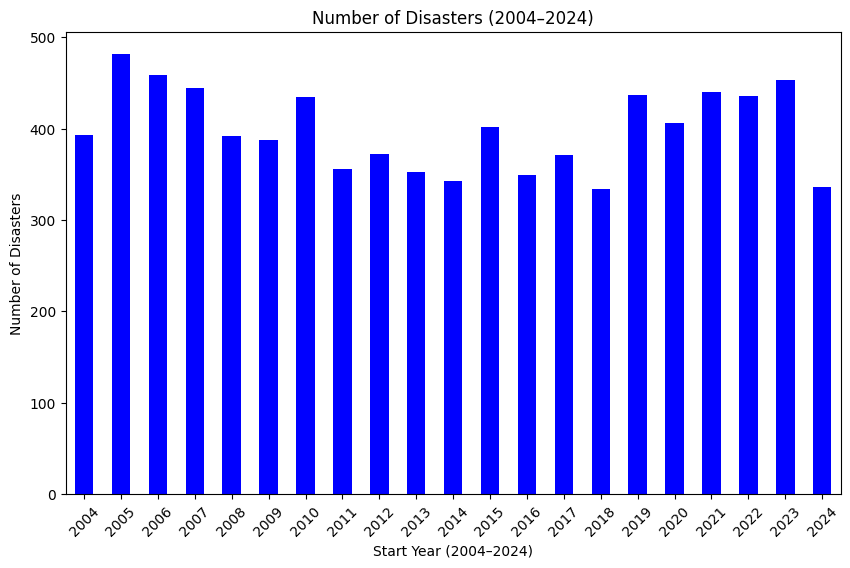

In [38]:
filtered = emdat[(emdat['Start Year'] >= 2004) & (emdat['Start Year'] <= 2024)]
disasters_2004_2024 = filtered.groupby('Start Year').size()
plt.figure(figsize=(10, 6))
disasters_2004_2024.plot(kind='bar', color='blue')
plt.xlabel('Start Year (2004–2024)')
plt.ylabel('Number of Disasters')
plt.title('Number of Disasters (2004–2024)')
plt.xticks(rotation=45)
plt.show()

過去の20年では増減に傾向はみられなかったが、すべての年で300件を超える災害が発生していることがわかる。
次に、2004年から2024年の地震の発生件数を調べてグラフにする。

年ごとの地震発生件数 (2004–2024)
| Start Year   | 0   |
|:-------------|:----|
| 2004         | 42  |
| 2005         | 25  |
| 2006         | 24  |
| 2007         | 21  |
| 2008         | 23  |
| 2009         | 22  |
| 2010         | 24  |
| 2011         | 30  |
| 2012         | 27  |
| 2013         | 29  |
| 2014         | 26  |
| 2015         | 23  |
| 2016         | 30  |
| 2017         | 22  |
| 2018         | 20  |
| 2019         | 31  |
| 2020         | 16  |
| 2021         | 28  |
| 2022         | 31  |
| 2023         | 32  |
| 2024         | 13  |


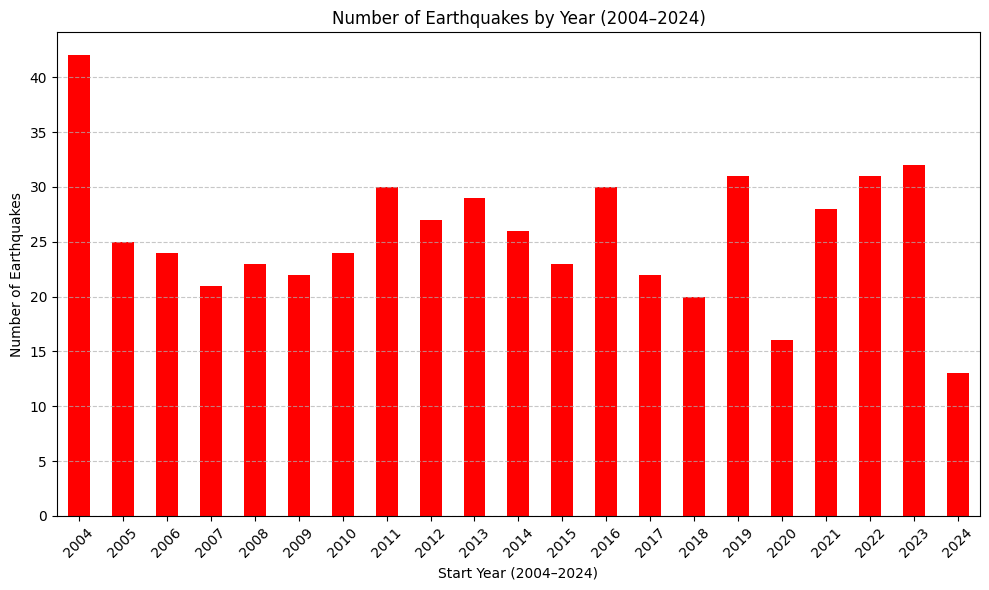

In [39]:
earthquake_filtered = df[
    (df['Start Year'] >= 2004) & 
    (df['Start Year'] <= 2024) & 
    (df['Disaster Type'] == 'Earthquake')
].copy()
earthquake_counts_yearly = earthquake_filtered.groupby('Start Year').size()
print("年ごとの地震発生件数 (2004–2024)")
print(earthquake_counts_yearly.to_markdown(numalign="left", stralign="left"))
plt.figure(figsize=(10, 6))
earthquake_counts_yearly.plot(kind='bar', color='red')
plt.xlabel('Start Year (2004–2024)')
plt.ylabel('Number of Earthquakes')
plt.title('Number of Earthquakes by Year (2004–2024)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

2004年の42件が最も多く、2024年の13件が最も少ない。だが、これも増減に傾向はないように見える。
ほかの災害でも同様に調べようと思うが、災害すべては多すぎるので、とくに多い4つのタイプとその他に分けようと思う。
いまから、とくに多い4つのタイプが何かを調べる。

In [40]:
df = pd.read_csv("emdat.csv")
disaster_type_counts = df['Disaster Type'].value_counts()
top_4_disaster_types = disaster_type_counts.head(4)
top_4_names = top_4_disaster_types.index.tolist()
print("上位4つの災害タイプ名（リスト）:", top_4_names)

上位4つの災害タイプ名（リスト）: ['Flood', 'Storm', 'Earthquake', 'Epidemic']


とくに多い4つの災害タイプは、洪水、嵐、地震、伝染病であった。
次にそれぞれの2004年から2024年の発生件数を調べる。

In [41]:
flood_filtered = df[
    (df['Start Year'] >= 2004) & 
    (df['Start Year'] <= 2024) & 
    (df['Disaster Type'] == 'Flood')
].copy()
flood_filtered_counts_yearly = flood_filtered.groupby('Start Year').size()
print("年ごとの洪水発生件数 (2004–2024)")
print(flood_filtered_counts_yearly.to_markdown(numalign="left", stralign="left"))

年ごとの洪水発生件数 (2004–2024)
| Start Year   | 0   |
|:-------------|:----|
| 2004         | 125 |
| 2005         | 190 |
| 2006         | 225 |
| 2007         | 215 |
| 2008         | 163 |
| 2009         | 151 |
| 2010         | 184 |
| 2011         | 153 |
| 2012         | 136 |
| 2013         | 148 |
| 2014         | 136 |
| 2015         | 161 |
| 2016         | 159 |
| 2017         | 127 |
| 2018         | 127 |
| 2019         | 195 |
| 2020         | 201 |
| 2021         | 222 |
| 2022         | 177 |
| 2023         | 163 |
| 2024         | 125 |


In [42]:
storm_filtered = df[
    (df['Start Year'] >= 2004) & 
    (df['Start Year'] <= 2024) & 
    (df['Disaster Type'] == 'Storm')
].copy()
storm_filtered_counts_yearly = storm_filtered.groupby('Start Year').size()
print("年ごとの嵐発生件数 (2004–2024)")
print(storm_filtered_counts_yearly.to_markdown(numalign="left", stralign="left"))

年ごとの嵐発生件数 (2004–2024)
| Start Year   | 0   |
|:-------------|:----|
| 2004         | 124 |
| 2005         | 130 |
| 2006         | 76  |
| 2007         | 104 |
| 2008         | 112 |
| 2009         | 87  |
| 2010         | 94  |
| 2011         | 84  |
| 2012         | 91  |
| 2013         | 105 |
| 2014         | 99  |
| 2015         | 121 |
| 2016         | 86  |
| 2017         | 130 |
| 2018         | 95  |
| 2019         | 92  |
| 2020         | 126 |
| 2021         | 121 |
| 2022         | 109 |
| 2023         | 139 |
| 2024         | 126 |


In [43]:
earthquake_filtered = df[
    (df['Start Year'] >= 2004) & 
    (df['Start Year'] <= 2024) & 
    (df['Disaster Type'] == 'Earthquake')
].copy()
earthquake_counts_yearly = earthquake_filtered.groupby('Start Year').size()
print("年ごとの地震発生件数 (2004–2024)")
print(earthquake_counts_yearly.to_markdown(numalign="left", stralign="left"))

年ごとの地震発生件数 (2004–2024)
| Start Year   | 0   |
|:-------------|:----|
| 2004         | 42  |
| 2005         | 25  |
| 2006         | 24  |
| 2007         | 21  |
| 2008         | 23  |
| 2009         | 22  |
| 2010         | 24  |
| 2011         | 30  |
| 2012         | 27  |
| 2013         | 29  |
| 2014         | 26  |
| 2015         | 23  |
| 2016         | 30  |
| 2017         | 22  |
| 2018         | 20  |
| 2019         | 31  |
| 2020         | 16  |
| 2021         | 28  |
| 2022         | 31  |
| 2023         | 32  |
| 2024         | 13  |


In [44]:
epidemic_filtered = df[
    (df['Start Year'] >= 2004) & 
    (df['Start Year'] <= 2024) & 
    (df['Disaster Type'] == 'Epidemic')
].copy()
epidemic_counts_yearly = epidemic_filtered.groupby('Start Year').size()
print("年ごとの伝染病発生件数 (2004–2024)")
print(epidemic_counts_yearly.to_markdown(numalign="left", stralign="left"))

年ごとの伝染病発生件数 (2004–2024)
| Start Year   | 0   |
|:-------------|:----|
| 2004         | 34  |
| 2005         | 53  |
| 2006         | 57  |
| 2007         | 35  |
| 2008         | 41  |
| 2009         | 44  |
| 2010         | 41  |
| 2011         | 27  |
| 2012         | 25  |
| 2013         | 23  |
| 2014         | 21  |
| 2015         | 16  |
| 2016         | 25  |
| 2017         | 27  |
| 2018         | 17  |
| 2019         | 37  |
| 2020         | 7   |
| 2021         | 7   |
| 2022         | 18  |
| 2023         | 16  |
| 2024         | 2   |


最後にこれらを合体させていく。

<Figure size 1500x800 with 0 Axes>

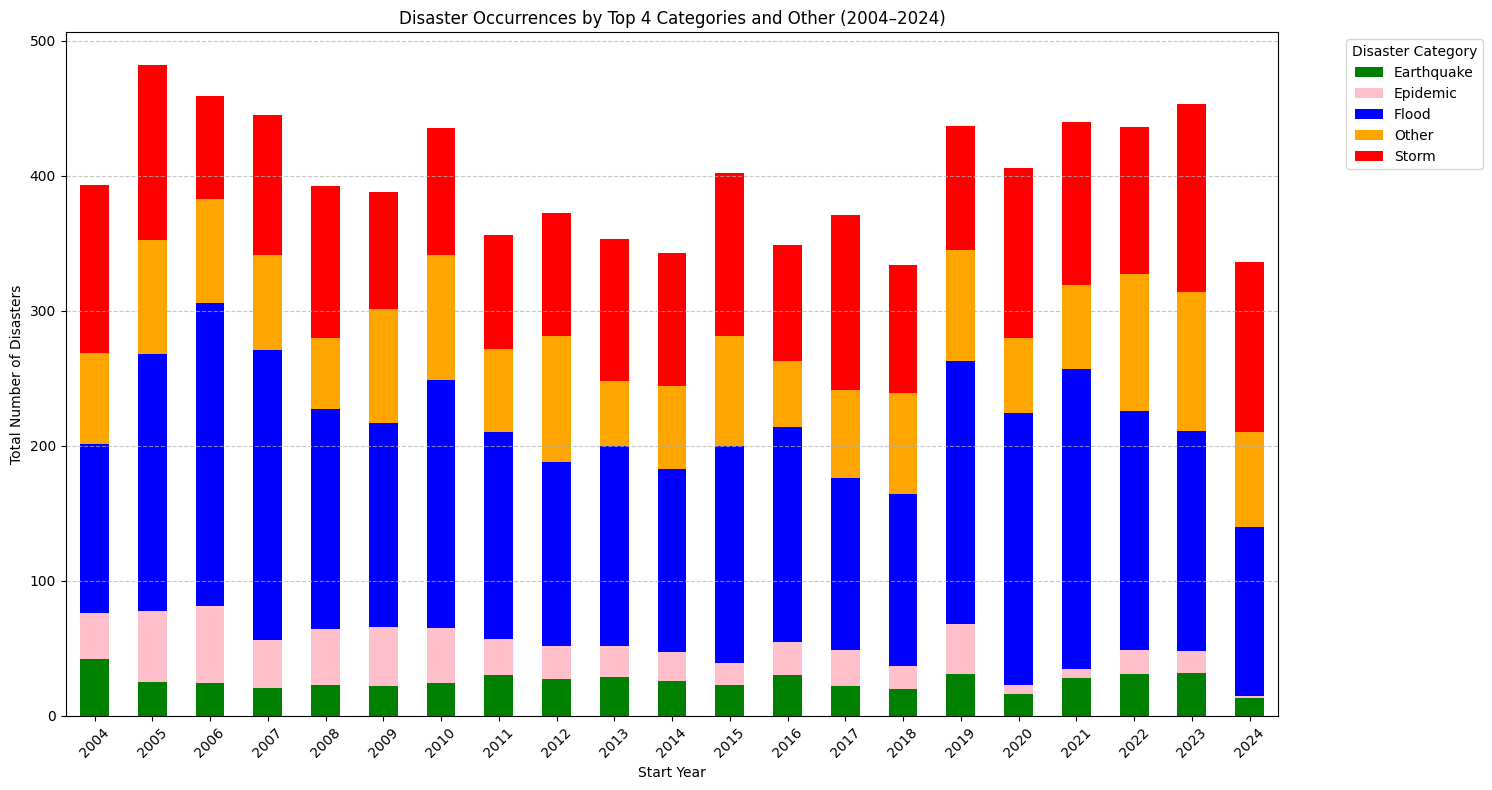

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("emdat.csv")

disaster_type_counts = df['Disaster Type'].value_counts()
top_4_disasters = disaster_type_counts.head(4).index.tolist()

filtered_data = df[
    (df['Start Year'] >= 2004) & 
    (df['Start Year'] <= 2024)
].copy()

filtered_data['Disaster Category'] = filtered_data['Disaster Type'].apply(
    lambda x: x if x in top_4_disasters else 'Other'
)
disaster_counts_by_year_category = filtered_data.groupby(['Start Year', 'Disaster Category']).size().unstack(fill_value=0)

custom_colors = ['green', 'pink', 'blue', 'orange', 'red']

plt.figure(figsize=(15, 8))

ax = disaster_counts_by_year_category.plot(
    kind='bar', 
    stacked=True, 
    figsize=(15, 8), 
    color=custom_colors
)

plt.xlabel('Start Year')
plt.ylabel('Total Number of Disasters')
plt.title('Disaster Occurrences by Top 4 Categories and Other (2004–2024)')

plt.legend(title='Disaster Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

できた。
赤がStorm(嵐)、オレンジがOther(その他)、青がFlood(洪水)、ピンクがEpidemic(伝染病)、緑がEarthquake(地震)である。
どの年も洪水が最も割合が高いことがわかる。
また、最近では伝染病が減っていることもわかる。
医療が発達し、伝染病への対策ができてきたのかもしれない。